In [1]:
import scanpy as sc
from pathlib import Path
import sys
repo_root = Path('/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_codes/STFateFlow')
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

adata = sc.read_h5ad("/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_data/ARTISTA/Regeneration_affine_preprocessed_ae.h5ad")

sc.experimental.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,
    batch_key="Batch",
    subset=True,
    chunksize=500,
)

/data/yuz/envs/nicheflow/lib/python3.11/site-packages/anndata/_core/anndata.py:1878: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/data/yuz/tmp/ipykernel_975724/1611687024.py:10: UserWarning: `flavor='pearson_residuals'` expects raw count data, but non-integers were found.
  sc.experimental.pp.highly_variable_genes(
/data/yuz/envs/nicheflow/lib/python3.11/site-packages/anndata/_core/anndata.py:1878: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [ ]:
# Cell 36: 准备参数与公共组件 + 计算并保存 FGWOT pi（不使用 wandb）
working_dir =  "/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_data/ot_pis"
data_name = "artista"
fgw_alpha = 0.5
seed = 42

# New option: whether to normalize OT plan mass to 1.
# True keeps previous behavior.
ot_plan_normalize = False

from pathlib import Path
import numpy as np
from moscot.problems.spatiotemporal import SpatioTemporalProblem

# 5) FGWOT pi 缓存路径（本单元只写入，不读取）
pi_cache_dir = Path(working_dir)
pi_cache_dir.mkdir(parents=True, exist_ok=True)
pi_cache_path = pi_cache_dir / f"fgwot_pi_{data_name}_alpha{fgw_alpha}_gene_triu.npz"

# 6) 计算每个相邻时间段 FGWOT 的 pi 并保存
print("Computing FGWOT pi and writing cache...")
adata_for_fgw = adata
spatial_key = "X_spatial_input"
# adata_for_fgw.obsm['X_ae'] = adata_for_fgw.obsm['X_ae'] / adata_for_fgw.obsm['X_ae'].max()

time_series = adata_for_fgw.obs["time"]
time_values = sorted(np.unique(time_series.to_numpy()).tolist())

problem = SpatioTemporalProblem(adata_for_fgw)

problem = problem.prepare(
    time_key="time",
    spatial_key=spatial_key,
    policy="triu",
    joint_attr={"attr": "X"},   # 关键：直接用 adata.X，不做默认 PCA
    cost={
        "xy": "sq_euclidean",   # gene expression term
        "x": "sq_euclidean",    # source spatial structure
        "y": "sq_euclidean",    # target spatial structure
    },
)
problem = problem.solve(alpha=float(fgw_alpha), epsilon=0, rank=200, tau_a = 0.97, tau_b = 0.93)

pi_by_transition = {}
cache_payload = {}
for i in range(len(time_values) - 1):
    for j in range(i + 1, i + 3):
        if j >= len(time_values):
            continue
        timea = time_values[i]
        timeb = time_values[j]
        if (timea, timeb) not in problem.solutions:
            print(f"Warning: No solution for transition {timea}->{timeb}. Skipping.")
            continue
        pi = np.asarray(problem.solutions[(timea, timeb)].transport_matrix, dtype=np.float64)
        pi = np.clip(pi, a_min=0.0, a_max=None)
        mass = float(pi.sum())
        if mass <= 0:
            raise ValueError(f"Invalid pi mass for transition {timea}->{timeb}")
        if ot_plan_normalize:
            pi = pi / mass
        pi_by_transition[(timea, timeb)] = pi
        cache_payload[f"transition_{timea}_{timeb}"] = pi
        print(f"transition {timea}->{timeb}, pi shape={pi.shape}, total mass={float(pi.sum()):.6f}")

np.savez_compressed(pi_cache_path, **cache_payload)
print(f"Saved FGWOT pi cache to: {pi_cache_path}")
# del adata_for_fgw

# 7) 统一 run_id（用于 checkpoint 路径，不依赖 wandb）
run_id = f"notebook_seed{seed}"

print("seed:", seed)
print("run_id:", run_id)
print("data_name:", data_name)
print("fgw_alpha:", fgw_alpha)
print("ot_plan_normalize:", ot_plan_normalize)
print("precomputed transitions:", sorted(pi_by_transition.keys()))
print("pi_cache_path:", pi_cache_path)
print("WandB disabled in this notebook pipeline.")

Computing FGWOT pi and writing cache...
INFO     Normalizing spatial coordinates of `x`.                                                                   
INFO     Normalizing spatial coordinates of `y`.                                                                   
WARNING  Densifying data in `adata.X`                                                                              
WARNING  Densifying data in `adata.X`                                                                              
INFO     Normalizing spatial coordinates of `x`.                                                                   
INFO     Normalizing spatial coordinates of `y`.                                                                   
WARNING  Densifying data in `adata.X`                                                                              
WARNING  Densifying data in `adata.X`                                                                              
INFO     Normalizing spatial coo

2026-07-07 16:41:53,895 | INFO | jax._src.xla_bridge | Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(8106, 9663)].                                  
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(7668, 11316)].                                 
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(7668, 9436)].                                  
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(9663, 11316)].                                 
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(9436, 11316)].                                 
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(8106, 11316)].                                 
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(8106, 9436)].                                  
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(7668, 9663)].                                  
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(7668

In [ ]:
# Cell 37: 读取 FGWOT pi 缓存并构建 ot_sampler
import importlib
import core.utils.fgwot as fgwot_mod
import numpy as np

ot_plan_normalize = False
dataset_name = "artista" #mosta_subset_unaffine
fgw_alpha = 0.5

fgwot_mod = importlib.reload(fgwot_mod)
FGWOTPlanSampler = fgwot_mod.FGWOTPlanSampler

# New option: whether to normalize OT plan after loading.
# If cell 36 already set this value, reuse it.
ot_plan_normalize = bool(globals().get('ot_plan_normalize', True))
working_dir =  "/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_data/ot_pis"
pi_cache_dir = Path(working_dir)
pi_cache_dir.mkdir(parents=True, exist_ok=True)
# Keep cache feature space consistent with this notebook pipeline (X_ae).
pi_cache_path = pi_cache_dir / f"fgwot_pi_{dataset_name}_alpha{fgw_alpha}_gene_triu.npz"
pi_by_transition = {}
if pi_cache_path.exists():
    print(f"Loading precomputed FGWOT pi from: {pi_cache_path}")
    cached = np.load(pi_cache_path, allow_pickle=False)
    transition_keys = []
    for key in cached.files:
        if key.startswith("transition_"):
            timea = float(key.split("_")[1])
            timeb = float(key.split("_")[2])
            transition_keys.append((timea, timeb))
            pi = np.asarray(cached[key], dtype=np.float64)
            pi = np.clip(pi, a_min=0.0, a_max=None)
            mass = float(pi.sum())
            if mass <= 0:
                raise ValueError(f"Invalid cached pi mass for transition {timea}->{timeb}")
            if ot_plan_normalize:
                pi = pi / mass
            pi_by_transition[(timea, timeb)] = pi
    if not transition_keys:
        raise ValueError(f"No transition_* arrays found in cache: {pi_cache_path}")
    print("Loaded transitions:", sorted(transition_keys))
else:
    raise FileNotFoundError(f"FGWOT cache not found: {pi_cache_path}")

ot_sampler = FGWOTPlanSampler(pi_matrix=pi_by_transition, normalize_pi=ot_plan_normalize)
print("ot_sampler:", type(ot_sampler).__name__)
print("transitions:", sorted(pi_by_transition.keys()))
print("ot_plan_normalize:", ot_plan_normalize)
print("example shape:", pi_by_transition[(0, 1)].shape if (0, 1) in pi_by_transition else "N/A")
if (0, 1) in pi_by_transition:
    print("example total mass:", float(np.asarray(pi_by_transition[(0, 1)]).sum()))

Loading precomputed FGWOT pi from: /data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_data/ot_pis/fgwot_pi_artista_alpha0.5_ae_triu.npz
Loaded transitions: [(2.0, 5.0), (2.0, 10.0), (5.0, 10.0), (5.0, 15.0), (10.0, 15.0), (10.0, 20.0), (15.0, 20.0)]
ot_sampler: FGWOTPlanSampler
transitions: [(2.0, 5.0), (2.0, 10.0), (5.0, 10.0), (5.0, 15.0), (10.0, 15.0), (10.0, 20.0), (15.0, 20.0)]
ot_plan_normalize: False
example shape: N/A


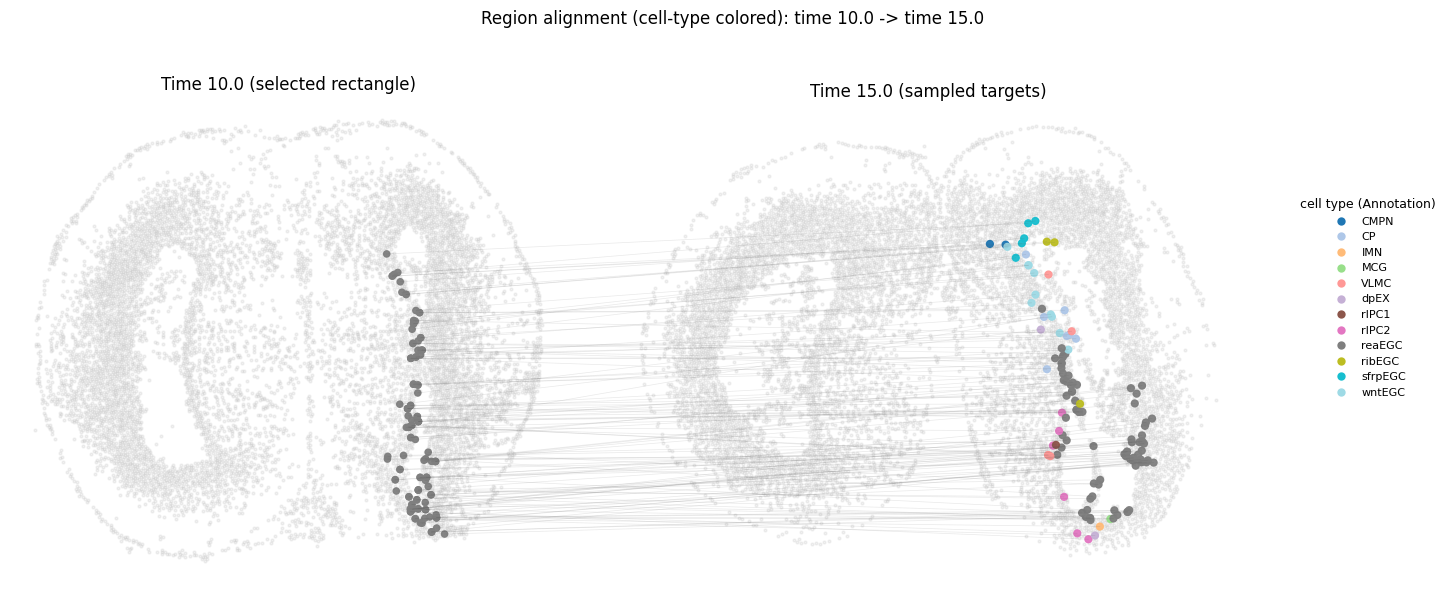

selected rectangle: x in [-0.25, -0.1], y in [-0.5, -0.35]
matched transition key: (10.0, 15.0), transposed: False
sampling mode: sample_map-style global flatten on region block, seed=2026, replace=True
cell type key: Annotation
drawn source cells (with replacement): 120
unique sampled source cells in t=10.0: 73
unique sampled cells in t=15.0: 110
cell types in aligned pairs: 12


In [ ]:
# 指定局部区域对齐可视化（按细胞类型着色）
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch
from matplotlib.lines import Line2D

source_timepoint = 10.0
target_timepoint = 15.0

# 1) 取两个时间点数据
t_obs_key = "time"
times = np.asarray(adata.obs[t_obs_key]).astype(float)
maska = np.isclose(times, source_timepoint)
maskb = np.isclose(times, target_timepoint)

Sa_all = np.asarray(adata.obsm["X_spatial_input"][maska], dtype=np.float64)
Sb_all = np.asarray(adata.obsm["X_spatial_input"][maskb], dtype=np.float64)

na, nb = Sa_all.shape[0], Sb_all.shape[0]
if na == 0 or nb == 0:
    raise ValueError("No cells found at time=2.0 or time=10.0")

obs_type_key = "Annotation"

def _get_types(mask, n):
    if obs_type_key is None:
        return np.array(["unknown"] * n, dtype=object)
    vals = np.asarray(adata.obs.loc[mask, obs_type_key]).astype(str)
    vals[vals == "nan"] = "unknown"
    return vals

types10_all = _get_types(maska, na)
types15_all = _get_types(maskb, nb)

# 2) 选取指定矩形区域
# x_min, x_max = -0.1, 0.1
# y_min, y_max = -0.7, -0.5

# region_mask = (
#     (Sa_all[:, 0] >= x_min)
#     & (Sa_all[:, 0] <= x_max)
#     & (Sa_all[:, 1] >= y_min)
#     & (Sb_all[:, 1] <= y_max)
# )
# region_idx = np.where(region_mask)[0]
# region_idx = np.where(adata[adata.obs['time'] == 10.0].obs['Annotation'].isin(["reaEGC", "rIPC1", "IMN", "nptxEX"]))[0]
region_idx = np.where(adata[adata.obs['time'] == source_timepoint].obs['Annotation'].isin(["reaEGC"]))[0]

# 可选: 限制连线数，避免图过密
max_lines = 360
if region_idx.size > max_lines:
    rng_sub = np.random.default_rng(42)
    region_idx = np.sort(rng_sub.choice(region_idx, size=max_lines, replace=False))

# 3) 自动匹配对应时间段的对齐矩阵
matched_key = None
P = None
transposed = False

for k in sorted(pi_by_transition.keys()):
    pi = np.asarray(pi_by_transition[k], dtype=np.float64)
    if pi.ndim != 2:
        continue
    if pi.shape == (na, nb) or pi.shape == (nb, na):
        matched_key = k
        P = pi
        transposed = False if pi.shape == (na, nb) else True
        break

# 4) sample_map 风格采样（在区域子矩阵上 flatten 采样）
P_nonneg = np.clip(P, a_min=0.0, a_max=None)
P_region = P_nonneg[region_idx, :]  # shape: (n_region, nb)

total_mass = float(P_region.sum())
if total_mass <= 1e-16:
    raise ValueError("Selected region has zero transport mass; cannot sample.")

p_flat = (P_region / total_mass).reshape(-1)
sample_seed = 2026
rng = np.random.default_rng(sample_seed)

choices = rng.choice(
    P_region.shape[0] * P_region.shape[1],
    size=region_idx.size,
    replace=True,
    p=p_flat,
)
row_local, aligned_idx = np.divmod(choices, P_region.shape[1])

source_idx = region_idx[row_local]
Sa_region = Sa_all[source_idx]
Sb_aligned = Sb_all[aligned_idx]

# 当前对齐对的细胞类型（左右各自按对应时间点类型着色）
type_src = types10_all[source_idx]
type_tgt = types15_all[aligned_idx]
types_union = np.unique(np.concatenate([type_src, type_tgt]))
n_types = int(types_union.size)

if n_types <= 20:
    cmap = plt.get_cmap("tab20", max(n_types, 1))
else:
    cmap = plt.get_cmap("gist_ncar", n_types)
type_to_color = {t: cmap(i) for i, t in enumerate(types_union)}

colors_src = [type_to_color[t] for t in type_src]
colors_tgt = [type_to_color[t] for t in type_tgt]

# 5) 可视化
fig, axes = plt.subplots(1, 2, figsize=(15.5, 6))
ax_l, ax_r = axes

x_min, x_max = -0.25, -0.1
y_min, y_max = -0.5, -0.35

ax_l.scatter(Sa_all[:, 0], Sa_all[:, 1], s=4, c="#c8c8c8", alpha=0.25, label=f"t={source_timepoint} other")
ax_l.scatter(Sa_region[:, 0], Sa_region[:, 1], s=20, c=colors_src, alpha=0.95, label=f"selected region (by cell type)")
# ax_l.plot([x_min, x_max, x_max, x_min, x_min], [y_min, y_min, y_max, y_max, y_min], color="#d62728", lw=1.5)
ax_l.set_title(f"Time {source_timepoint}")
ax_l.set_aspect("equal", adjustable="box")
ax_l.set_axis_off()

ax_r.scatter(Sb_all[:, 0], Sb_all[:, 1], s=4, c="#c8c8c8", alpha=0.25, label=f"t={target_timepoint} other")
ax_r.scatter(Sb_aligned[:, 0], Sb_aligned[:, 1], s=24, c=colors_tgt, alpha=0.95, label="sampled aligned targets (by cell type)")
ax_r.set_title(f"Time {target_timepoint}")
ax_r.set_aspect("equal", adjustable="box")
ax_r.set_axis_off()

n_lines = Sa_region.shape[0]
for i in range(n_lines):
    con = ConnectionPatch(
        xyA=(Sa_region[i, 0], Sa_region[i, 1]),
        coordsA=ax_l.transData,
        xyB=(Sb_aligned[i, 0], Sb_aligned[i, 1]),
        coordsB=ax_r.transData,
        color="#4f4f4f",
        alpha=0.12,
        lw=0.5,
    )
    fig.add_artist(con)

# 图例过多时只展示前若干类，避免遮挡
legend_limit = 30
types_for_legend = sorted(types_union.tolist())
if len(types_for_legend) > legend_limit:
    shown_types = types_for_legend[:legend_limit]
    hidden_n = len(types_for_legend) - legend_limit
else:
    shown_types = types_for_legend
    hidden_n = 0

handles = [
    Line2D([0], [0], marker="o", linestyle="", markersize=6, markerfacecolor=type_to_color[t], markeredgecolor="none", label=t)
    for t in shown_types
]
if hidden_n > 0:
    handles.append(Line2D([0], [0], linestyle="", label=f"... +{hidden_n} more types"))

fig.legend(
    handles=handles,
    loc="center left",
    bbox_to_anchor=(0.86, 0.5),
    frameon=False,
    title=f"cell type ({obs_type_key if obs_type_key else 'fallback'})",
    fontsize=8,
    title_fontsize=9,
)
plt.suptitle(f"Region alignment: t = {source_timepoint} -> time = {target_timepoint}")
plt.tight_layout(rect=[0, 0, 0.84, 0.95])
plt.show()

print(f"selected rectangle: x in [{x_min}, {x_max}], y in [{y_min}, {y_max}]")
print(f"matched transition key: {matched_key}, transposed: {transposed}")
print(f"sampling mode: sample_map-style global flatten on region block, seed={sample_seed}, replace=True")
print(f"cell type key: {obs_type_key if obs_type_key is not None else 'None (fallback=unknown)'}")
print(f"drawn source cells (with replacement): {Sa_region.shape[0]}")
print(f"unique sampled source cells in t={source_timepoint}: {np.unique(source_idx).size}")
print(f"unique sampled cells in t={target_timepoint}: {np.unique(aligned_idx).size}")
print(f"cell types in aligned pairs: {n_types}")

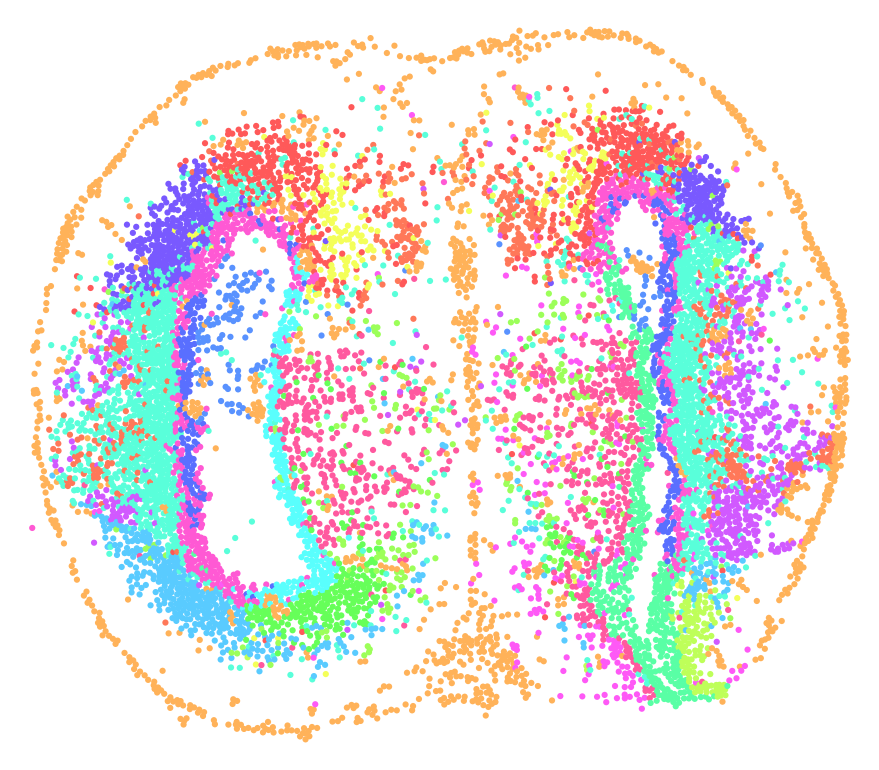

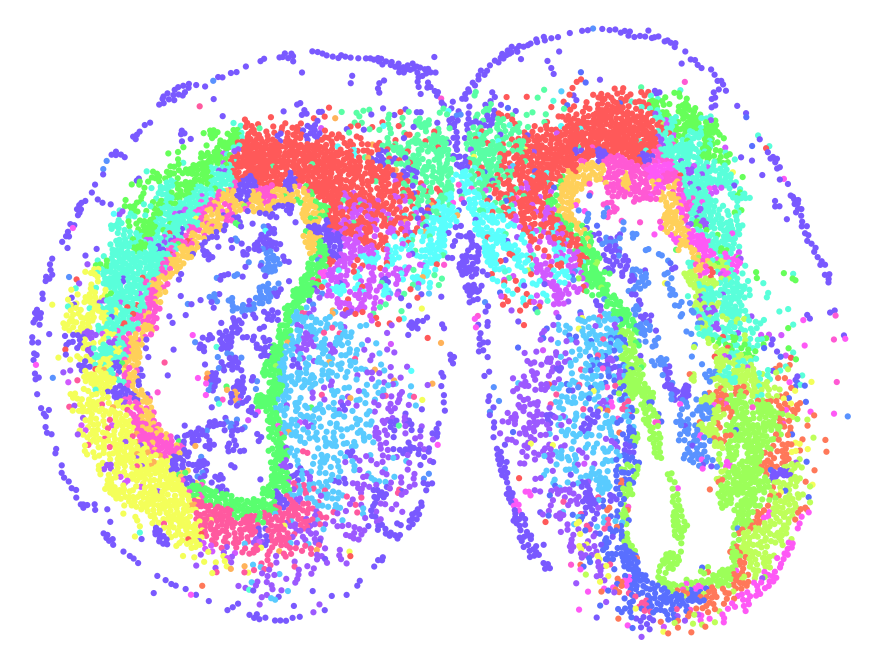

In [6]:
# 分别可视化两个时间点完整切片：按 cell type 着色，不显示 title / 坐标轴 / 图例
from matplotlib.colors import ListedColormap

def plot_slice_by_cell_type(adata, timepoint, spatial_key='X_spatial_input', time_key='time', cell_type_key='Annotation', point_size=5.0):
    times = np.asarray(adata.obs[time_key]).astype(float)
    mask = np.isclose(times, float(timepoint))
    coords = np.asarray(adata.obsm[spatial_key][mask], dtype=np.float64)
    if coords.shape[0] == 0:
        raise ValueError(f'No cells found at time={timepoint}')
    coords = coords[:, :2]

    cell_types = adata.obs.loc[mask, cell_type_key].astype(str).to_numpy()
    levels = np.unique(cell_types)
    type_to_idx = {ct: i for i, ct in enumerate(levels)}
    color_idx = np.asarray([type_to_idx[ct] for ct in cell_types], dtype=int)

    n_types = len(levels)
    if n_types <= 0:
        colors = np.asarray(['#ffffff'], dtype=object)
    else:
        hues = (np.arange(n_types) * 0.618033988749895) % 1.0
        rgb = plt.cm.hsv(hues)[:, :3]
        colors = 0.35 + 0.65 * rgb
    cmap = ListedColormap(colors)

    fig, ax = plt.subplots(figsize=(4.2, 4.2), dpi=200)
    ax.scatter(
        coords[:, 0],
        coords[:, 1],
        c=color_idx,
        cmap=cmap,
        s=point_size,
        marker='o',
        edgecolors='none',
        linewidths=0,
        alpha=1.0,
    )
    ax.set_aspect('equal', adjustable='box')
    ax.set_axis_off()
    x_pad = 0.015 * max(np.ptp(coords[:, 0]), 1e-8)
    y_pad = 0.015 * max(np.ptp(coords[:, 1]), 1e-8)
    ax.set_xlim(coords[:, 0].min() - x_pad, coords[:, 0].max() + x_pad)
    ax.set_ylim(coords[:, 1].min() - y_pad, coords[:, 1].max() + y_pad)
    plt.tight_layout(pad=0)
    plt.show()


plot_slice_by_cell_type(adata, source_timepoint)
plot_slice_by_cell_type(adata, target_timepoint)
